In [1]:
import GWDALI as gw
import numpy as np
import matplotlib.pyplot as plt

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Setting detectors network

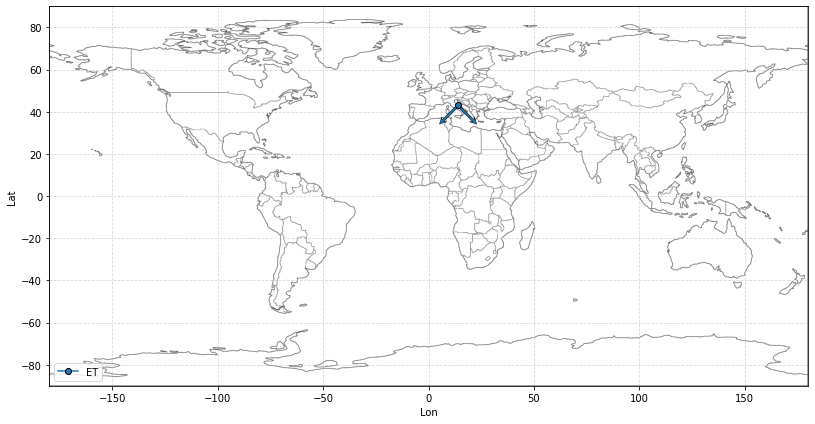

In [2]:
detectors = [ {'name':'ET','lon':14, 'lat':43, 'rot':-45, 'shape':90} ] # Single L-shape detector with ET sensitivity

fig = gw.draw_detectors(detectors)

## Setting GW source parameters

For GW Polarizations computing it is necessary to declare **15 parameters** (see [https://gwdali.readthedocs.io/en/latest/gw_sources.html](https://gwdali.readthedocs.io/en/latest/gw_sources.html) ):

* Mass parameters: 2 
    * {m1, m2, Mc, eta, M, q, deltaM, inv_eta, ln_eta, ln_Mc}
* Distance Parameters: 1 
    * {dL, inv_dL, inv_dL2, inv_sqrtdL, lnDL, inv_lnDL}
* Spins Parameters: 6 
    * (Cartesian / Spherical / Symmetric-Antisymmetric)
* Extrinsic Parameters: 6 
    * (iota/cos_iota , phi_coal, t_coal, RA, Dec, psi)

In [3]:
GwPrms = {}                                                                                                
GwPrms['dL'] 	= 10.96
GwPrms['Mc'] 	= 9.57
GwPrms['eta'] 	= 0.25
GwPrms['iota'] 	= 0.52
GwPrms['psi'] 	= 2.32
GwPrms['t_coal'] 	= 0.00
GwPrms['phi_coal'] 	= -1.37
GwPrms['RA'] 	= -135.75
GwPrms['Dec'] 	= 72.92
GwPrms['sz1'] 	= 0.31
GwPrms['sz2'] 	= 0.16

GwPrms['sx1'] 	= 0.00
GwPrms['sy1'] 	= 0.00

GwPrms['sx2'] 	= 0.00
GwPrms['sy2'] 	= 0.00

In [4]:
freq = np.logspace(1,3,1000)

FreeParams = "dL,iota,psi,phi_coal,RA,Dec,t_coal,Mc,eta,sz1,sz2".split(',') # Derivatives are computed with respect to these parameters
N = len(FreeParams)

### Computing Derivatives (Numerical Method)

In [5]:
# It returns the derivatives and its corresponding evaluation time

Diff_values_ndf, time_diff_ndf = gw.get_derivatives(	FreeParams = FreeParams,
														approx = "TaylorF2",
														GwPrms = GwPrms,
														detectors = detectors,
														freq = freq,
														diff_order = "second",
														diff_method = "numdiff", # numerical derivative
														step_size = 1.e-5,  # relative step size
														enable_jax_waveforms = True,
														EarthRotation = False
													)

>> Computing Derivatives with respect to: ['dL', 'iota', 'psi', 'phi_coal', 'RA', 'Dec', 't_coal', 'Mc', 'eta', 'sz1', 'sz2'] 

Computing Second-Order Derivatives ...
	 (dL,dL)	 [1-66]	 Diff[dL,dL] OK! 	(1 seconds)
	 (iota,dL)	 [2-66]	 Diff[iota,dL] OK! 	(0 seconds)
	 (iota,iota)	 [3-66]	 Diff[iota,iota] OK! 	(0 seconds)
	 (psi,dL)	 [4-66]	 Diff[psi,dL] OK! 	(0 seconds)
	 (psi,iota)	 [5-66]	 Diff[psi,iota] OK! 	(0 seconds)
	 (psi,psi)	 [6-66]	 Diff[psi,psi] OK! 	(0 seconds)
	 (phi_coal,dL)	 [7-66]	 Diff[phi_coal,dL] OK! 	(0 seconds)
	 (phi_coal,iota)	 [8-66]	 Diff[phi_coal,iota] OK! 	(0 seconds)
	 (phi_coal,psi)	 [9-66]	 Diff[phi_coal,psi] OK! 	(0 seconds)
	 (phi_coal,phi_coal)	 [10-66]	 Diff[phi_coal,phi_coal] OK! 	(0 seconds)
	 (RA,dL)	 [11-66]	 Diff[RA,dL] OK! 	(0 seconds)
	 (RA,iota)	 [12-66]	 Diff[RA,iota] OK! 	(0 seconds)
	 (RA,psi)	 [13-66]	 Diff[RA,psi] OK! 	(0 seconds)
	 (RA,phi_coal)	 [14-66]	 Diff[RA,phi_coal] OK! 	(0 seconds)
	 (RA,RA)	 [15-66]	 Diff[RA,RA] OK! 	(0 seconds)

### Automatic Differentiation and JIT Compilation

The following example shows how to compute second-order derivatives using JAX automatic differentiation (**diff_method = "autodiff"**). The outputs returned by **gw.get_derivatives()** are therefore evaluated through autodiff instead of finite-difference methods.

In addition, users may enable *just-in-time* (JIT) compilation to accelerate future derivative evaluations. When **jitgrad = True**, the gradients are internally compiled through:

```python
jax.jit(jax.grad(...))
```

This can significantly improve performance after the initial compilation step, particularly when the same waveform structure is evaluated multiple times.

However, users should be careful when enabling JIT for computationally expensive waveform approximants such as "IMRPhenomHM", since the compilation stage itself can become extremely costly in both runtime and memory usage.

In [6]:
Diff_values_adf, time_diff_adf = gw.get_derivatives(	FreeParams = FreeParams,
                                                        approx = "TaylorF2",
                                                        GwPrms = GwPrms,
                                                        detectors = detectors,
                                                        freq = freq,
                                                        diff_order = "second",
                                                        diff_method = "autodiff", # automatic differentiation
                                                        jitgrad = False,
                                                        enable_jax_waveforms = True,
                                                        EarthRotation = False
                                                    )

>> Computing Derivatives with respect to: ['dL', 'iota', 'psi', 'phi_coal', 'RA', 'Dec', 't_coal', 'Mc', 'eta', 'sz1', 'sz2'] 

	 loading <autodiff> derivatives ...
		>> jitgrad = False...
	 <autodiff> derivatives loaded!

Computing Second-Order Derivatives ...
	 (dL,dL)	 [1-66]	 Diff[dL,dL] OK! 	(0 seconds)
	 (iota,dL)	 [2-66]	 Diff[iota,dL] OK! 	(0 seconds)
	 (iota,iota)	 [3-66]	 Diff[iota,iota] OK! 	(0 seconds)
	 (psi,dL)	 [4-66]	 Diff[psi,dL] OK! 	(0 seconds)
	 (psi,iota)	 [5-66]	 Diff[psi,iota] OK! 	(0 seconds)
	 (psi,psi)	 [6-66]	 Diff[psi,psi] OK! 	(0 seconds)
	 (phi_coal,dL)	 [7-66]	 Diff[phi_coal,dL] OK! 	(0 seconds)
	 (phi_coal,iota)	 [8-66]	 Diff[phi_coal,iota] OK! 	(0 seconds)
	 (phi_coal,psi)	 [9-66]	 Diff[phi_coal,psi] OK! 	(0 seconds)
	 (phi_coal,phi_coal)	 [10-66]	 Diff[phi_coal,phi_coal] OK! 	(0 seconds)
	 (RA,dL)	 [11-66]	 Diff[RA,dL] OK! 	(0 seconds)
	 (RA,iota)	 [12-66]	 Diff[RA,iota] OK! 	(0 seconds)
	 (RA,psi)	 [13-66]	 Diff[RA,psi] OK! 	(1 seconds)
	 (RA,phi_coal


### Checking Outputs

* **N**: number of parameters used for derivations

* **Diff_values**: Array of derivatives
    - For first order derivatives it has shape: N x len(freq)
    - For second order derivatives it has shape: N x N x len(freq)
    - For third order derivatives it has shape: N x N x N x len(freq)

* **time_diff = [time_array, total_time]**
    - time_array: Array of individual evaluation time of independent derivatives
    - total_time: The total evaluation time for computing all independent derivatives

In [7]:
time_array_adf, total_time_adf = time_diff_adf
time_array_ndf, total_time_ndf = time_diff_ndf

print(np.shape(Diff_values_adf))
print(np.shape(time_array_adf)) # number of independent derivatives
print(type(total_time_adf))
print()
print(f"Total Time [Numerical Derivatives]:     {total_time_ndf:.2f} seconds")
print(f"Total Time [Automatic Differentiation]: {total_time_adf:.2f} seconds")

(11, 11, 1000)
(66,)
<class 'float'>

Total Time [Numerical Derivatives]:     38.05 seconds
Total Time [Automatic Differentiation]: 68.13 seconds


### Storing Results

In [8]:
second_diffs_ndf = [] # Bellow I'm going to store only the independent derivatives
second_diffs_adf = []

tabs = [] ; n = 0

for i in range(N):
    for j in range(i+1):
        Diff_ndf = Diff_values_ndf[i][j] # Second derivative with respect to the parameters FreeParams[i] and FreeParams[j]
        Diff_adf = Diff_values_adf[i][j]

        diff_key = f"({FreeParams[i]}, {FreeParams[j]})"
        
        second_diffs_ndf.append(Diff_ndf)
        second_diffs_adf.append(Diff_adf)
        
        tabs.append([diff_key, time_array_ndf[n], time_array_adf[n]])
        n+=1
        

### Showing Time Results With "Tabulate"

In [9]:
from tabulate import tabulate

In [10]:
print( tabulate(tabs, headers=["Parameters", "Evaluation Time\n[numdiff]\n(seconds)", "Evaluation Time\n[autodiff]\n(seconds)"], 
                tablefmt='psql', colalign=["left","center","center"], floatfmt=".4f") )

+----------------------+-------------------+-------------------+
| Parameters           |  Evaluation Time  |  Evaluation Time  |
|                      |     [numdiff]     |    [autodiff]     |
|                      |     (seconds)     |     (seconds)     |
|----------------------+-------------------+-------------------|
| (dL, dL)             |      1.0425       |      0.9160       |
| (iota, dL)           |      0.6018       |      0.4889       |
| (iota, iota)         |      0.5557       |      0.4343       |
| (psi, dL)            |      0.5651       |      0.5418       |
| (psi, iota)          |      0.5660       |      0.3987       |
| (psi, psi)           |      0.5649       |      0.6012       |
| (phi_coal, dL)       |      0.5653       |      0.5333       |
| (phi_coal, iota)     |      0.5567       |      0.4684       |
| (phi_coal, psi)      |      0.5841       |      0.4724       |
| (phi_coal, phi_coal) |      0.5838       |      0.4297       |
| (RA, dL)             | 

### Plotting 2nd Order Derivatives

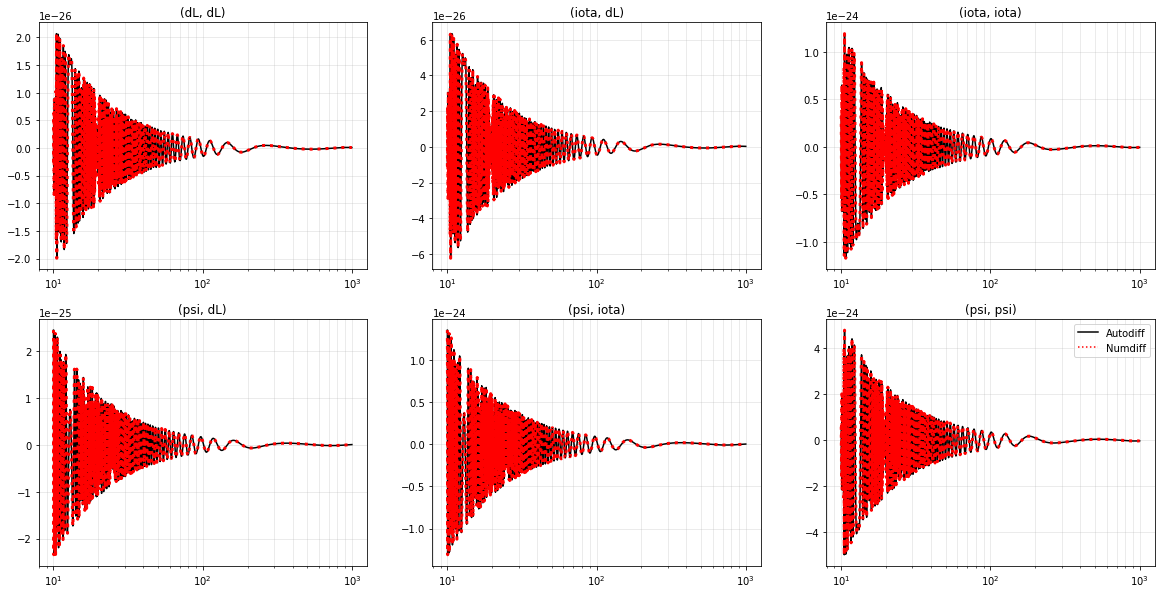

In [11]:
fig = plt.figure(figsize=(20,10))

Amp = lambda x: np.sqrt( np.real(x*np.conj(x)) )

for i in range(6):
    plt.subplot(2,3,i+1)
    dh1 = second_diffs_adf[i].real
    dh2 = second_diffs_ndf[i].real

    plt.plot(freq,dh1,'k-')
    plt.plot(freq,dh2,'r:',lw=3)
    plt.title(tabs[i][0])
    plt.xscale('log')
    plt.grid(which='both',alpha=.3)

plt.plot([],'k-',label='Autodiff')
plt.plot([],'r:',label='Numdiff')
plt.legend(loc='best')
